In [1]:
import pandas as pd

df = pd.read_csv('play_by_play_2025.csv')
df.head()

/tmp/ipykernel_1750/2190859021.py:3: DtypeWarning: Columns (45,179,180,182,183,189,190,203,204,205,206,218,219,220,222,224,226,233,234,235,236,237,238,253,254,255,260,262,263,283,284) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('play_by_play_2025.csv')


,play_id,game_id,old_game_id,home_team,away_team,season_type,week,posteam,posteam_type,defteam,...,out_of_bounds,home_opening_kickoff,qb_epa,xyac_epa,xyac_mean_yardage,xyac_median_yardage,xyac_success,xyac_fd,xpass,pass_oe
0,1,2025_01_ARI_NO,2025090705,NO,ARI,REG,1,NaN,NaN,NaN,...,0,0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,40,2025_01_ARI_NO,2025090705,NO,ARI,REG,1,ARI,away,NO,...,0,0,-0.352700,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,63,2025_01_ARI_NO,2025090705,NO,ARI,REG,1,ARI,away,NO,...,0,0,-0.190052,NaN,NaN,NaN,NaN,NaN,0.511128,-51.112807
3,85,2025_01_ARI_NO,2025090705,NO,ARI,REG,1,ARI,away,NO,...,1,0,1.317340,0.939998,4.750889,3.0,0.666726,0.43911,0.668940,33.105969
4,115,2025_01_ARI_NO,2025090705,NO,ARI,REG,1,ARI,away,NO,...,0,0,-1.694360,NaN,NaN,NaN,NaN,NaN,0.492038,50.796208


Correlação: 0.105


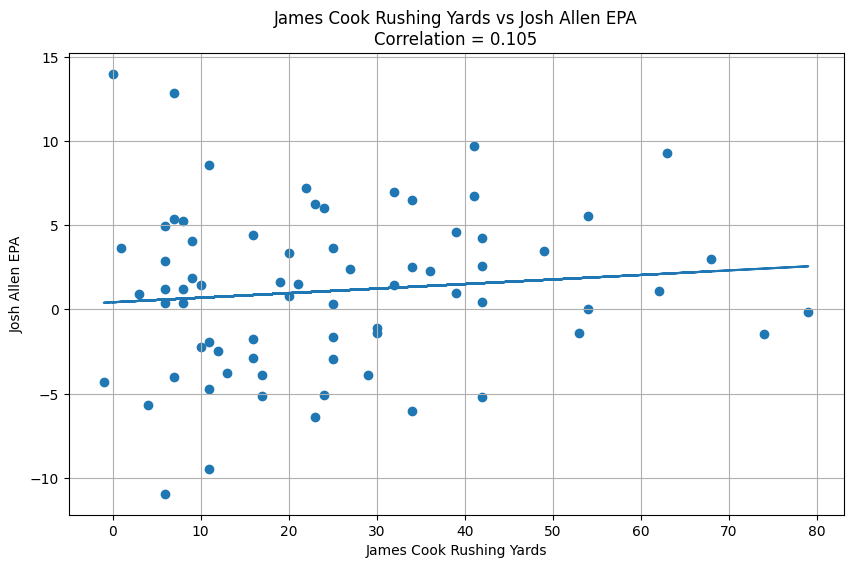

            quartile       epa
0  Q1 (menos jardas)  1.887305
1                 Q2 -0.527891
2                 Q3  0.443835
3   Q4 (mais jardas)  2.537511


/tmp/ipykernel_1750/3778160239.py:87: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('quartile')['epa']


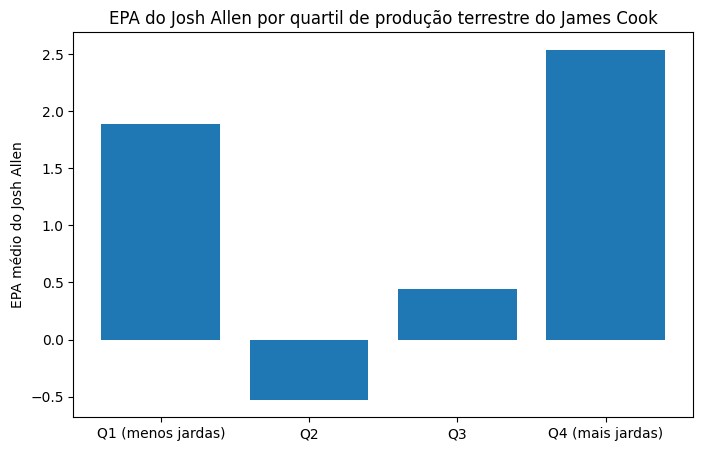

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# limpezinha básica / standard cleaning

df2 = df.copy()

df2['rusher'] = df2['rusher'].astype(str).str.strip()
df2['passer'] = df2['passer'].astype(str).str.strip()

# filtrando jogadas do Cook / filtering only James Cook plays
cook = (
    df2[df2['rusher'] == 'J.Cook']
    .groupby(['week', 'qtr'])['rushing_yards']
    .sum()
    .reset_index()
)

# filtrando passes do Allen / filtering only Josh Allen passes
allen = (
    df2[
        (df2['passer'] == 'J.Allen') &
        (df2['play_type'] == 'pass')
    ]
    .groupby(['week', 'qtr'])['epa']
    .sum()
    .reset_index()
)

# juntando as tabelas / merging tables
analysis = pd.merge(
    cook,
    allen,
    on=['week', 'qtr'],
    how='inner'
)

# correlação / correlation
corr = analysis['rushing_yards'].corr(
    analysis['epa']
)
print(f'Correlação: {corr:.3f}')

# scatter plot
plt.figure(figsize=(10,6))
plt.scatter(
    analysis['rushing_yards'],
    analysis['epa']
)

# linha de tendência / trend line
m, b = np.polyfit(
    analysis['rushing_yards'],
    analysis['epa'],
    1
)
plt.plot(
    analysis['rushing_yards'],
    m * analysis['rushing_yards'] + b
)
plt.xlabel('James Cook Rushing Yards')
plt.ylabel('Josh Allen EPA')
plt.title(
    f'James Cook Rushing Yards vs Josh Allen EPA\nCorrelation = {corr:.3f}'
)
plt.grid(True)
plt.show()

analysis['quartile'] = pd.qcut(
    analysis['rushing_yards'],
    4,
    labels=[
        'Q1 (menos jardas)',
        'Q2',
        'Q3',
        'Q4 (mais jardas)'
    ]
)

quartile_stats = (
    analysis
    .groupby('quartile')['epa']
    .mean()
    .reset_index()
)

print(quartile_stats)


plt.figure(figsize=(8,5))

plt.bar(
    quartile_stats['quartile'],
    quartile_stats['epa']
)

plt.ylabel('EPA médio do Josh Allen')
plt.title('EPA do Josh Allen por quartil de produção terrestre do James Cook')

plt.show()

Total de quartos analisados: 71
Correlação: 0.080


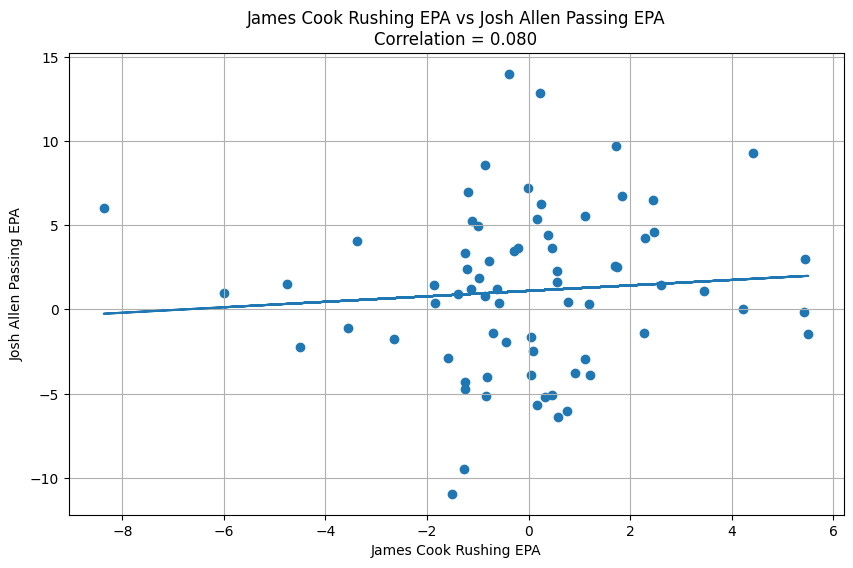

/tmp/ipykernel_1750/1667284566.py:93: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('quartile')['epa_allen']


              quartile  epa_allen
0  Q1 (EPA mais baixo)  -0.525045
1                   Q2   2.166409
2                   Q3  -0.139800
3   Q4 (EPA mais alto)   2.806773


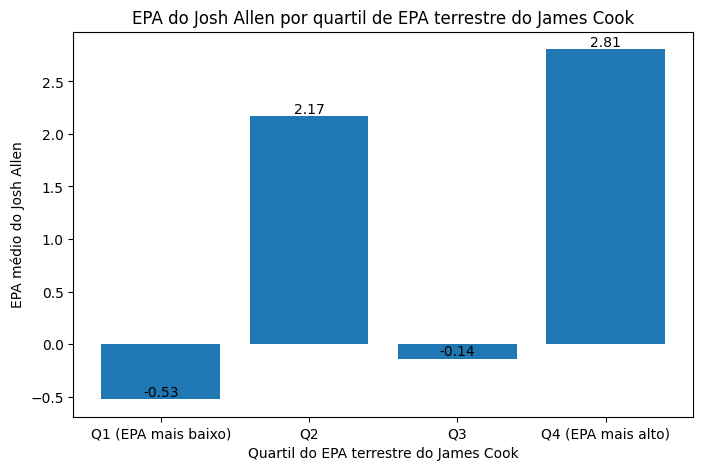

EPA Allen - Q1
count    18.000000
mean     -0.525045
std       4.780247
min     -10.942032
25%      -2.719908
50%       0.637207
75%       2.170794
max       6.993714
Name: epa_allen, dtype: float64

EPA Allen - Q4
count    18.000000
mean      2.806773
std       3.757968
min      -3.892496
25%       0.088003
50%       2.524098
75%       5.301303
max       9.711855
Name: epa_allen, dtype: float64
p-value: 0.026545923219893488


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# limpezinha básica / standard cleaning
df2 = df.copy()

df2['rusher'] = df2['rusher'].astype(str).str.strip()
df2['passer'] = df2['passer'].astype(str).str.strip()
df2['play_type'] = df2['play_type'].astype(str).str.lower().str.strip()

df2['epa'] = pd.to_numeric(df2['epa'], errors='coerce')


# EPA terrestre do Cook / James Cook rushing EPA
cook_epa = (
    df2[
        (df2['rusher'] == 'J.Cook') &
        (df2['play_type'] == 'run')
    ]
    .groupby(['week', 'qtr'])['epa']
    .sum()
    .reset_index()
)


# EPA de passe do Allen / Josh Allen passing EPA
allen_epa = (
    df2[
        (df2['passer'] == 'J.Allen') &
        (df2['play_type'] == 'pass')
    ]
    .groupby(['week', 'qtr'])['epa']
    .sum()
    .reset_index()
)

# juntando as tabelas / merging tables
analysis = pd.merge(
    cook_epa,
    allen_epa,
    on=['week', 'qtr'],
    suffixes=('_cook', '_allen')
)

print(f'Total de quartos analisados: {len(analysis)}')


# correlação / correlation
corr = analysis['epa_cook'].corr(
    analysis['epa_allen']
)
print(f'Correlação: {corr:.3f}')

# scatter plot
plt.figure(figsize=(10,6))
plt.scatter(
    analysis['epa_cook'],
    analysis['epa_allen']
)

# linha de tendência
m, b = np.polyfit(
    analysis['epa_cook'],
    analysis['epa_allen'],
    1
)
plt.plot(
    analysis['epa_cook'],
    m * analysis['epa_cook'] + b
)

plt.xlabel('James Cook Rushing EPA')
plt.ylabel('Josh Allen Passing EPA')
plt.title(
    f'James Cook Rushing EPA vs Josh Allen Passing EPA\nCorrelation = {corr:.3f}'
)
plt.grid(True)
plt.show()
analysis['quartile'] = pd.qcut(
    analysis['epa_cook'],
    4,
    labels=[
        'Q1 (EPA mais baixo)',
        'Q2',
        'Q3',
        'Q4 (EPA mais alto)'
    ]
)

quartile_stats = (
    analysis
    .groupby('quartile')['epa_allen']
    .mean()
    .reset_index()
)

print(quartile_stats)

plt.figure(figsize=(8,5))
plt.bar(
    quartile_stats['quartile'],
    quartile_stats['epa_allen']
)

plt.ylabel('EPA médio do Josh Allen')
plt.xlabel('Quartil do EPA terrestre do James Cook')
plt.title(
    'EPA do Josh Allen por quartil de EPA terrestre do James Cook'
)

for i, v in enumerate(quartile_stats['epa_allen']):
    plt.text(
        i,
        v,
        f'{v:.2f}',
        ha='center',
        va='bottom'
    )

plt.show()

q1 = analysis[analysis['quartile'] == 'Q1 (EPA mais baixo)']
q4 = analysis[analysis['quartile'] == 'Q4 (EPA mais alto)']
print("EPA Allen - Q1")
print(q1['epa_allen'].describe())
print("\nEPA Allen - Q4")
print(q4['epa_allen'].describe())

from scipy.stats import ttest_ind

t_stat, p_val = ttest_ind(
    q1['epa_allen'],
    q4['epa_allen'],
    equal_var=False
)

print("p-value:", p_val)